# <a id='toc1_'></a>[Digital signal processing. Lab2](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Digital signal processing. Lab2](#toc1_)    
  - [Task1](#toc1_1_)    
    - [Task1(a)](#toc1_1_1_)    
    - [Task1(b)](#toc1_1_2_)    
    - [Task1(c)](#toc1_1_3_)    
  - [Task2](#toc1_2_)    
  - [Task3](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%%capture 
%pip install matplotlib 
%pip install numpy
%pip install scipy

## <a id='toc1_1_'></a>[Task1](#toc0_)
На вход передатчика сигнала подается сигнал косинуса с частотами 50 и 150 Гц.
 
 * **(a)** Постройте дискретный спектр сигнала с помощью стандартной функции быстрого преобразования Фурье `fft()` и функции `DFT_slow()`. Сравните время вычисления этих двух функций.
 * **(b)** С помощью функции быстрого обратного преобразования Фурье `ifft()` убедитесь, что форма сигнала не изменилась.
  * **(c)** После распространения сигнала в линии на приемнике был получен сигнал, искаженный белым шумом. Постройте дискретный спектр зашумленного сигнала на приемнике. Возьмите обратное преобразование Фурье и посмотрите, как поменялась форма принятого сигнала после распространения в линии.

 **Замечание:** белый шум (Аддитивный белый гауссовский шум, [15]) можно добавить с помощью команды: `np.random.normal(0, 1, x.shape)`

### <a id='toc1_1_1_'></a>[Task1(a)](#toc0_)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [3]:
def DFT_slow(x):
    """Compute the discrete Fourier Transform of 1D array x"""
    x = np.asarray(x, dtype=float)
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, x)

In [4]:
f_1 = 50.0           
f_2 = 150.0

Fs = 2000 # частота дискретизации
dt = 1.0 / Fs # шаг по времени

w_1 = 2 * np.pi * f_1
w_2 = 2 * np.pi * f_2   

signal = lambda t : np.cos(w_1 * t) + np.cos(w_2 * t)

In [5]:
t_vals = np.arange(0, 1, dt)
signal_vals = signal(t_vals)

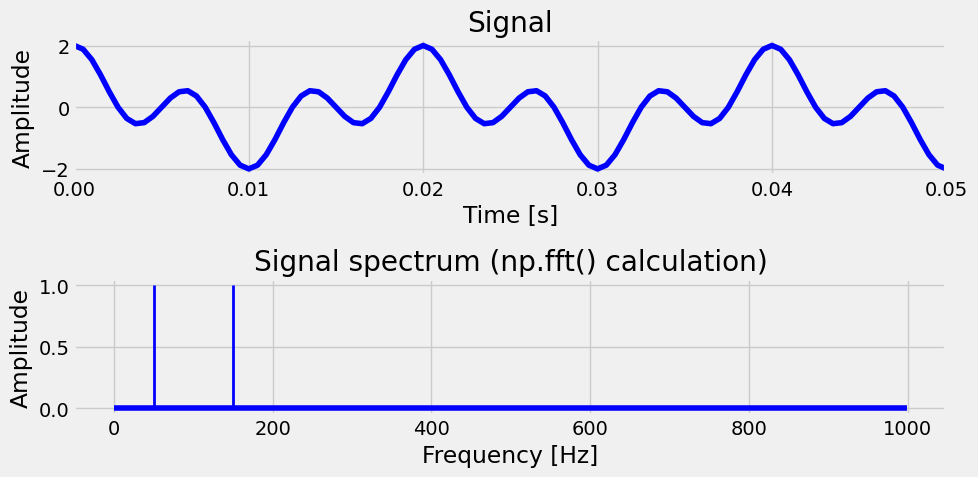

In [6]:
spectrum_fft = np.fft.fft(signal_vals)

N = signal_vals.shape[-1]

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals, signal_vals, 'b')
plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_fft[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

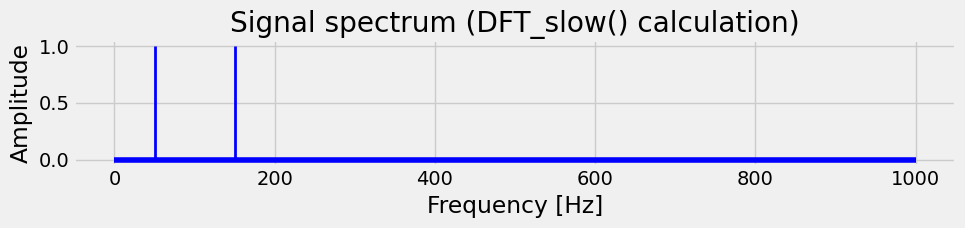

In [7]:
spectrum_slow = DFT_slow(signal_vals)

f_max = max(f_1, f_2)

xf = np.linspace(0.0, Fs/2, N//2)

plt.figure(figsize=(10, 2.5))

markerline, stemlines, baseline = plt.stem(xf, 2/N * np.abs(spectrum_slow[:N//2]))
plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (DFT_slow() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()


In [8]:
!lscpu | grep "Model name"
%timeit DFT_slow(signal_vals)
%timeit np.fft.fft(signal_vals)

Model name:                              12th Gen Intel(R) Core(TM) i5-12450H
115 ms ± 717 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
16.4 μs ± 167 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


| Обозначение | Название |Соотношение |
|:---:|:---:|:---:|
| **s** | секунда | $10^{0}$ с |
| **ms** | миллисекунда | $10^{-3}$ с |
| **µs** | микросекунда  | $10^{-6}$ с |
| **ns** | наносекунда  | $10^{-9}$ с |

**Результат теста:**
В моем тесте `DFT_slow` показал результат в **ms** (миллисекундах), а `np.fft.fft` — в **µs** (микросекундах). 
Разница между ними составляет три порядка ($1000$ раз). Таким образом, результат **16.4 µs** в тысячи раз быстрее, чем **117 ms**.

$$ 116\text{ ms} = 117\cdot10^{-3} = 0.117 \text{ с}$$

$$ 16\text{ µs} = 16\cdot10^{-6}  = 0.000016 \text{ с}$$

$$ \frac{0.117}{0.000016} \approx 7312 $$

### <a id='toc1_1_2_'></a>[Task1(b)](#toc0_)

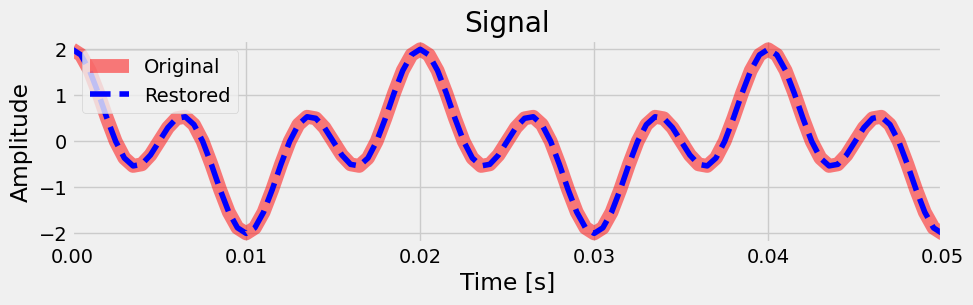

In [9]:
signal_vals_restored = np.fft.ifft(spectrum_fft)

plt.figure(figsize=(10, 2.5))

plt.plot(t_vals, signal_vals, 'r', label='Original',linewidth=10, alpha= 0.5)
plt.plot(t_vals, signal_vals_restored.real,'b--', label='Restored', linewidth=4.0)


plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')
plt.legend()
plt.show()

### <a id='toc1_1_3_'></a>[Task1(c)](#toc0_)

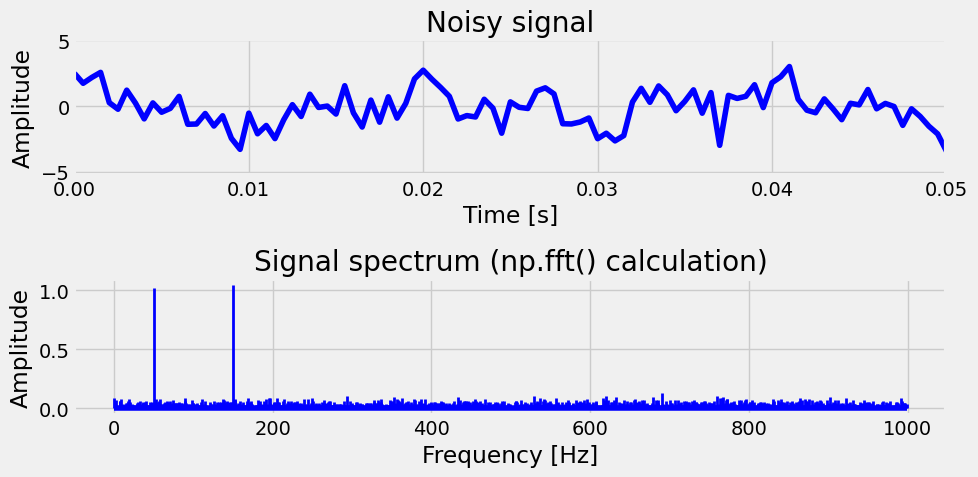

In [10]:
np.random.seed(42)

signal_vals_noise = signal_vals + np.random.normal(0, 1, N)

spectrum_noisy_fft = np.fft.fft(signal_vals_noise)

N = signal_vals_noise.shape[-1]

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals, signal_vals_noise, 'b')
plt.title('Noisy signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_noisy_fft[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

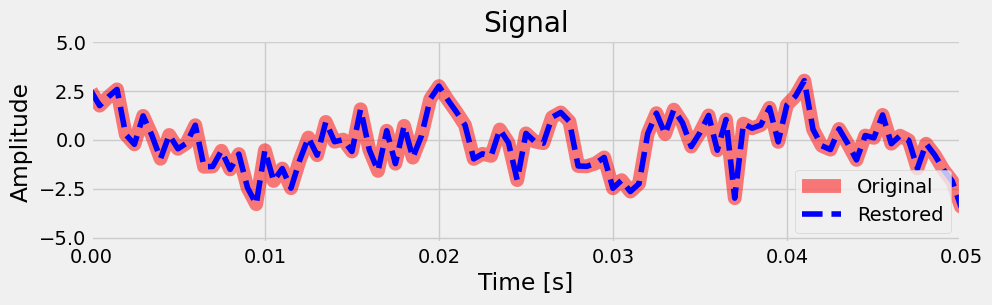

In [11]:
signal_vals_restored = np.fft.ifft(specfactor = np.exp(-2j * np.pi * np.arange(N) / N)
factortrum_noisy_fft)

plt.figure(figsize=(10, 2.5))

plt.plot(t_vals, signal_vals_noise, 'r', label='Original',linewidth=10, alpha= 0.5)
plt.plot(t_vals, signal_vals_restored.real, 'b--', label='Restored', linewidth=4.0)

plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## <a id='toc1_2_'></a>[Task2](#toc0_)
Исследуемый сигнал $x(t)$ описывается периодическими прямоугольными импульсами с амплитудой $A=2$, периодом $T=2$ на интервале времени от 0 до 4. Постройте дискретный спектр сигнала с помощью стандартной функции быстрого преобразования Фурье `fft()` и функции `DFT_slow()`. Наложите шум на данный сигнал, посмотрите спектр зашумленного сигнала.

In [12]:
T = 2
f = 1/T         
A = 2.0   
Fs = 300 
dt = 1.0 / Fs          
w = 2 * np.pi * f

x_func = lambda t: A * np.sign(np.sin(w * t))

In [13]:
t_vals2 = np.arange(0, 4, dt)
signal_vals2 = x_func(t_vals2)

signal_vals2.shape

(1200,)

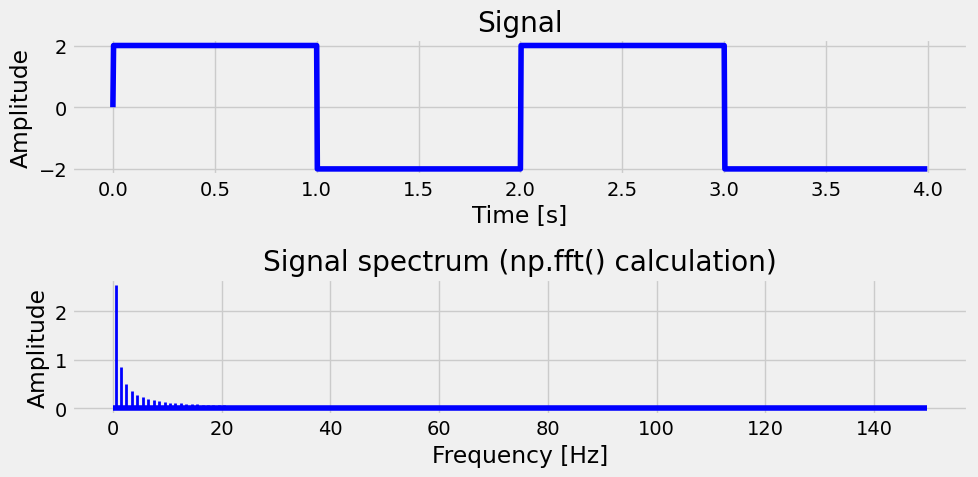

In [14]:
spectrum_fft2 = np.fft.fft(signal_vals2)

N = signal_vals2.shape[-1]

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals2, signal_vals2, 'b')
plt.title('Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_fft2[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

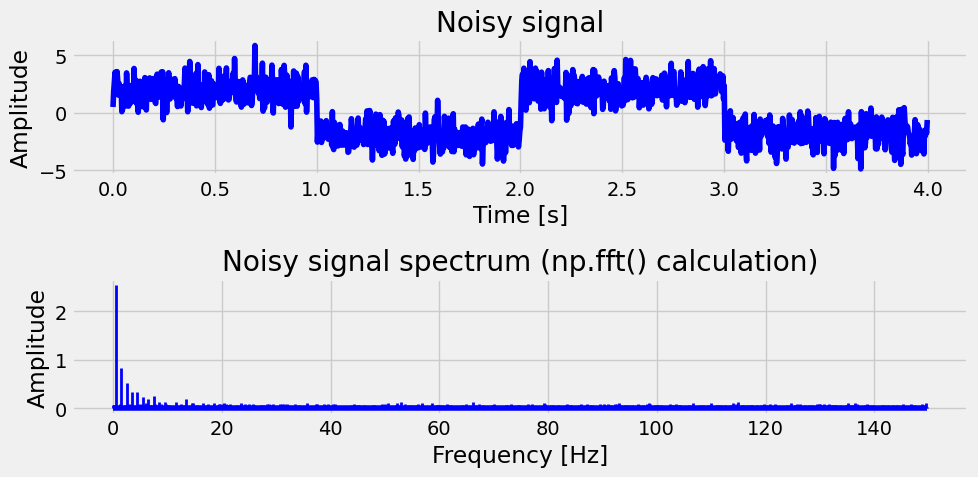

In [15]:
np.random.seed(42)

signal_vals2_noise = signal_vals2 + np.random.normal(0, 1, N)

spectrum_noisy2_fft = np.fft.fft(signal_vals2_noise)

freq = np.fft.fftfreq(N, dt)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals2, signal_vals2_noise, 'b')
plt.title('Noisy signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_noisy2_fft[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Noisy signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

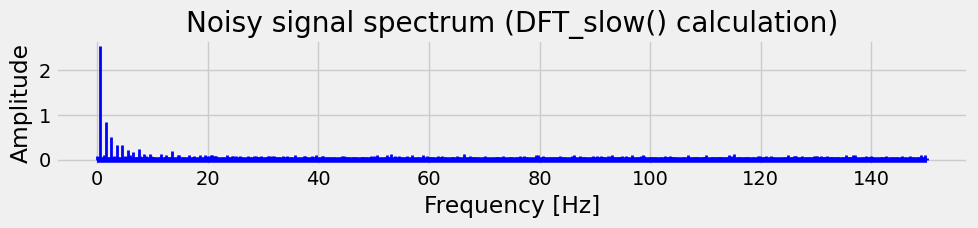

In [16]:
spectrum_noisy2_slow = DFT_slow(signal_vals2_noise)

xf = np.linspace(0.0, Fs/2, N//2)

plt.figure(figsize=(10, 2.5))

markerline, stemlines, baseline = plt.stem(xf, 2/N * np.abs(spectrum_noisy2_slow[:N//2]))
plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Noisy signal spectrum (DFT_slow() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()


## <a id='toc1_3_'></a>[Task3](#toc0_)
Реализовать код для определения быстрого дискретного преобразования Фурье (БДПФ). Убедиться, что функция написана верно, для этого рассмотреть сигнал косинуса с частотой 50 Гц и убедиться, что сигнал имеет одну выделенную частоту 50 Гц. Сравните время выполнения написанного кода для реализации (БДПФ) с встроенной функцией (БДПФ) `fft()`.

In [96]:
def FFT(x, DEBUG_MODE = False):
    x = np.asarray(x)
    N = x.shape[0]
    
    if not ((N > 0) and (N & (N - 1)) == 0):
        if DEBUG_MODE:
            print("x(1D array) length is not a power of 2. Padding x to make it a power of 2.")
        
        degree = int(np.ceil(np.log2(N)))
        if DEBUG_MODE:
            print(f"The nearest degree=d of 2 such that 2^d > Length of x(1D array) is {degree}.")
            
        x = np.pad(x, (0, 2**degree - N), mode='constant')
        if DEBUG_MODE:
            print(f"New Length: {x.shape[0]} (2^{degree})")
    
    return _fft_core(x)

def _fft_core(x):
    N = x.shape[0]
    
    if N <= 32:
        return DFT_slow(x)
    
    X_odd = _fft_core(x[::2])
    X_even = _fft_core(x[1::2])
    
    factor = np.exp(-2j * np.pi * np.arange(N) / N)
    
    return np.concatenate([
        X_even + factor[:N // 2] * X_odd,
        X_even + factor[N // 2:] * X_odd
    ])

In [97]:
f_3 = 50.0

Fs_3 = 2000 
dt_3 = 1.0 / Fs_3 

w_3 = 2 * np.pi * f_3

signal = lambda t : np.cos(w_3 * t)

In [98]:
t_vals3 = np.arange(0, 1, dt_3)
signal_vals3 = signal(t_vals3)

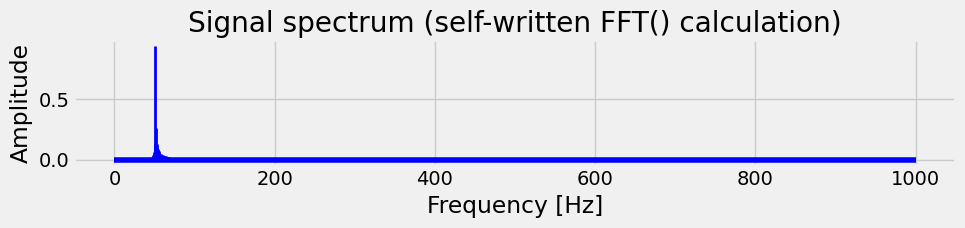

In [99]:
spectrum_my_fft = FFT(signal_vals3)

N = signal_vals3.shape[0]

xfft = np.linspace(0.0, Fs_3/2, N//2)

plt.figure(figsize=(10, 2.5))

markerline, stemlines, baseline = plt.stem(xfft, 2/N * np.abs(spectrum_my_fft[:N//2]))
plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (self-written FFT() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()


In [103]:
!lscpu | grep "Model name"
%timeit FFT(signal_vals3)
%timeit np.fft.fft(signal_vals3)

Model name:                              12th Gen Intel(R) Core(TM) i5-12450H
1.78 ms ± 23.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
16.4 μs ± 132 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


| Обозначение | Название |Соотношение |
|:---:|:---:|:---:|
| **s** | секунда | $10^{0}$ с |
| **ms** | миллисекунда | $10^{-3}$ с |
| **µs** | микросекунда  | $10^{-6}$ с |
| **ns** | наносекунда  | $10^{-9}$ с |

**Результат теста:**
В моем тесте `FFT` показал результат в **ms** (миллисекундах), а `np.fft.fft` — в **µs** (микросекундах). 
Разница между ними составляет три порядка ($1000$ раз). Таким образом, результат **16.4 µs** в тысячи раз быстрее, чем **117 ms**.

$$ 1.78\text{ ms} = 1.78\cdot10^{-3} = 0.00178 \text{ с}$$

$$ 16\text{ µs} = 16\cdot10^{-6}  = 0.000016 \text{ с}$$

$$ \frac{0.00178}{0.000016} \approx 105.5 $$

В то время как `DFT_slow` показал результат равный $116\text{ ms}$. Таким образом, коэффициент ускорения (speedup) самописного FFT() составил :
$$ S = \frac{116}{1.78} \approx 65 \text{ раз}$$